# Imports and Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)

csv_path = '../results/hybrid_benchmark_results.csv'
df = pd.read_csv(csv_path)

baselines = [
    {
        'dataset': 'data/sift_base.fvecs', 'M': 16, 'ef_construction': 200, 
        'batch_size': 'Baseline', 'candidates_per_query': 'Baseline', 
        'beam_search_ef': 'Baseline', 'seed_size': 'Baseline',
        'build_time_sec': 86.5564,     
        'throughput_vec_sec': 11553.2,  
        'recall_1': 0.9924,         
        'recall_10': 0.983099,          
        'links_to_seed': np.nan, 
        'links_to_hybrid': np.nan, 
        'isolated_nodes': 0,        
        'starved_nodes': 0,        
        'avg_out_degree': 21.2352,     
        'type': 'Pure CPU Baseline'
    },
    {
        'dataset': 'data/synthetic_768d_base.fvecs', 'M': 16, 'ef_construction': 200, 
        'batch_size': 'Baseline', 'candidates_per_query': 'Baseline', 
        'beam_search_ef': 'Baseline', 'seed_size': 'Baseline',
        'build_time_sec': 778.148,     
        'throughput_vec_sec': 1285.1,  
        'recall_1': 0.0936,         
        'recall_10': 0.0746591,      
        'links_to_seed': np.nan, 
        'links_to_hybrid': np.nan, 
        'isolated_nodes': 0,       
        'starved_nodes': 0,      
        'avg_out_degree': 19.1812,     
        'type': 'Pure CPU Baseline'
    }
]

df['type'] = 'Hybrid CPU-GPU'
df = pd.concat([df, pd.DataFrame(baselines)], ignore_index=True)

df['dataset_clean'] = df['dataset'].apply(lambda x: 'SIFT (128D)' if 'sift' in x else 'Synthetic (768D)')

print("Data loaded successfully! Total runs:", len(df))

Data loaded successfully! Total runs: 110


### Seed graph

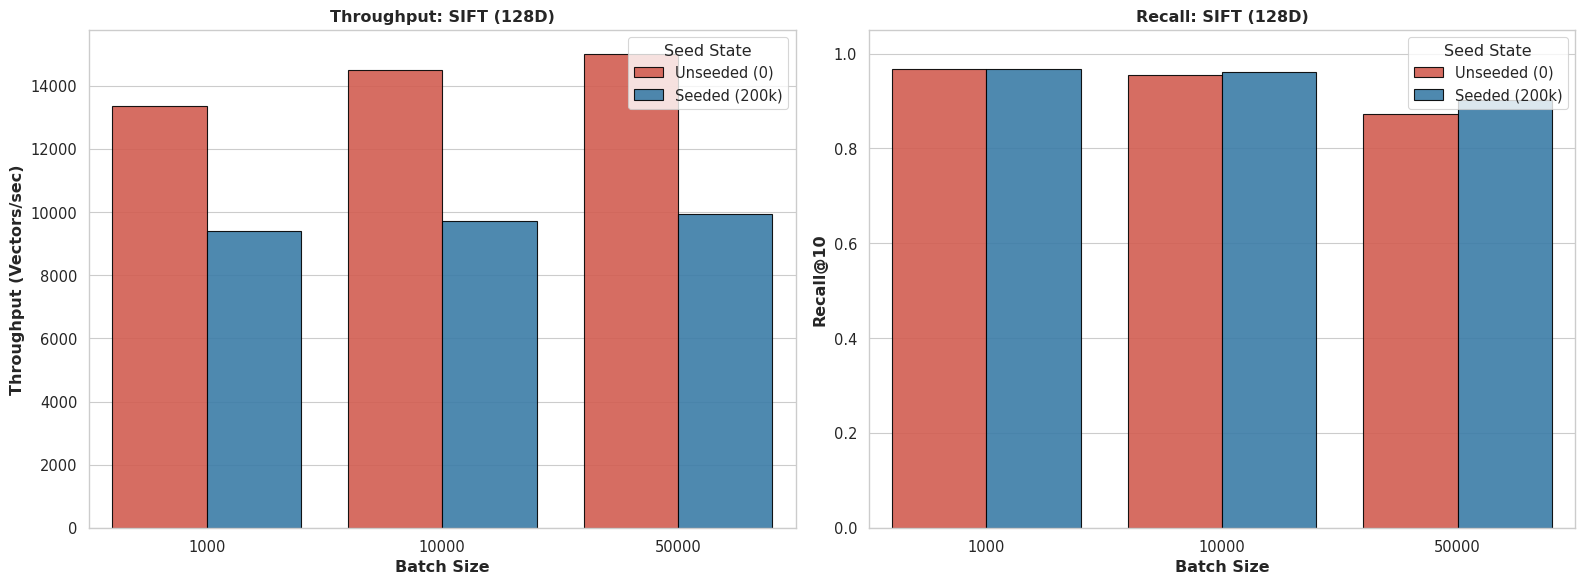

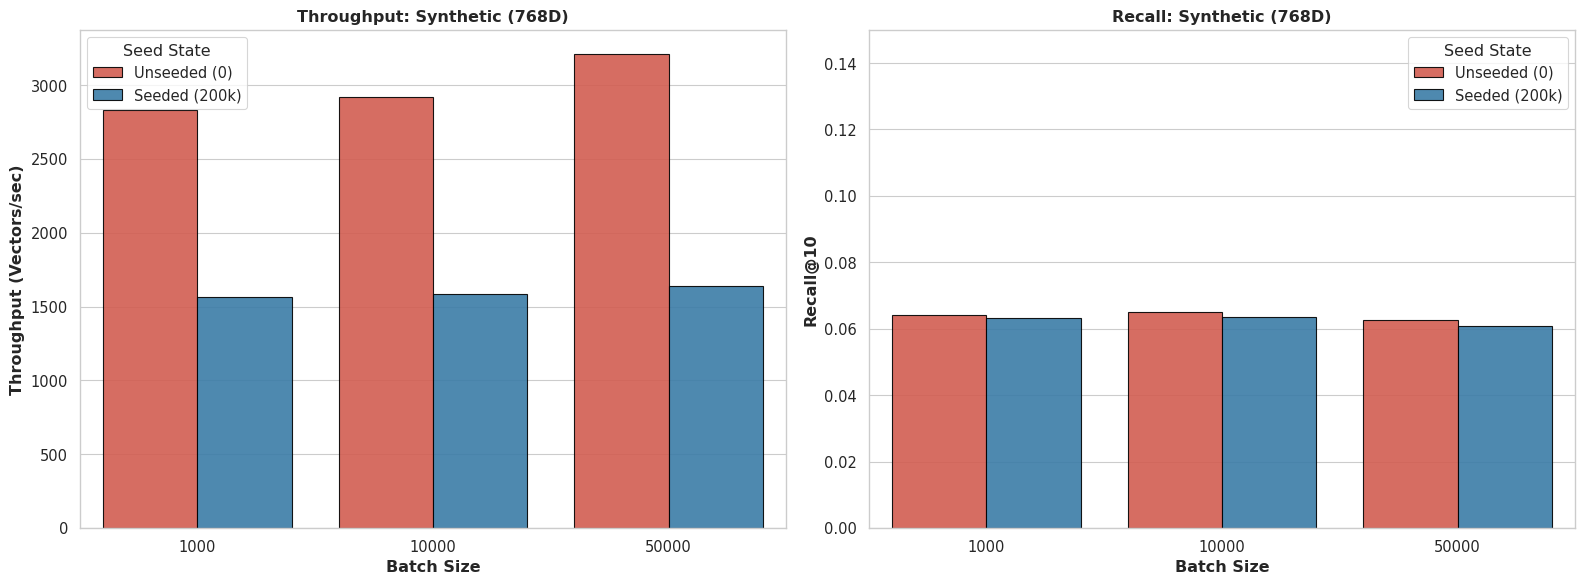

In [ ]:
sq1_df = df[(df['type'] == 'Hybrid CPU-GPU') & 
            (df['candidates_per_query'] == 3000) & 
            (df['beam_search_ef'] == 10)].copy()

sq1_df['batch_size'] = pd.Categorical(sq1_df['batch_size'], categories=[1000, 10000, 50000], ordered=True)
sq1_df['Seed State'] = sq1_df['seed_size'].apply(lambda x: 'Unseeded (0)' if int(x) == 0 else 'Seeded (200k)')

datasets = ['SIFT (128D)', 'Synthetic (768D)']

for ds_name in datasets:
    sub_df = sq1_df[sq1_df['dataset_clean'] == ds_name]
    if sub_df.empty: 
        continue
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Throughput Bar Chart
    sns.barplot(
        data=sub_df, x='batch_size', y='throughput_vec_sec', hue='Seed State', 
        palette=['#e74c3c', '#2980b9'], edgecolor='black', alpha=0.9, ax=axes[0]
    )
    axes[0].set_title(f'Throughput: {ds_name}', fontweight='bold')
    axes[0].set_xlabel('Batch Size', fontweight='bold')
    axes[0].set_ylabel('Throughput (Vectors/sec)', fontweight='bold')
    
    # Recall Bar Chart 
    sns.barplot(
        data=sub_df, x='batch_size', y='recall_10', hue='Seed State', 
        palette=['#e74c3c', '#2980b9'], edgecolor='black', alpha=0.9, ax=axes[1]
    )
    axes[1].set_title(f'Recall: {ds_name}', fontweight='bold')
    axes[1].set_xlabel('Batch Size', fontweight='bold')
    axes[1].set_ylabel('Recall@10', fontweight='bold')
    
    if ds_name == 'Synthetic (768D)':
        axes[1].set_ylim(0, 0.15) 
    else:
        axes[1].set_ylim(0, 1.05)

    plt.tight_layout()
    clean_name = ds_name.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f'sq1_bar_charts_{clean_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Batching

### Throughput and Recall 

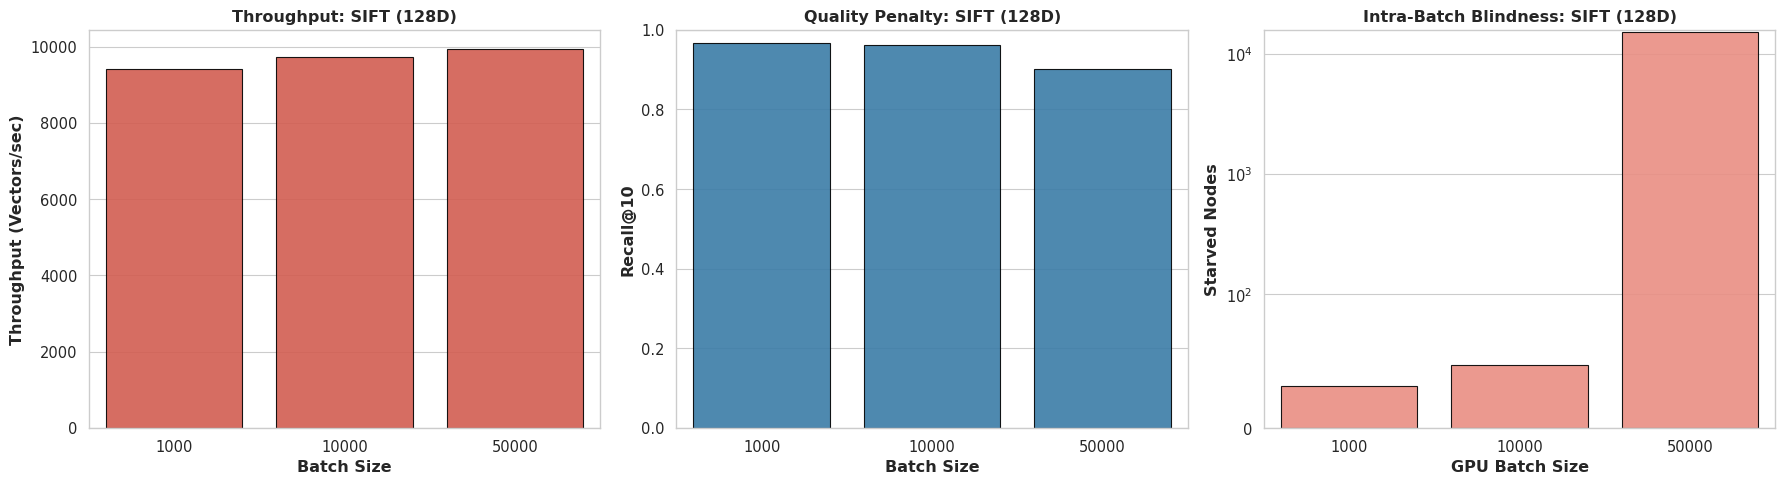

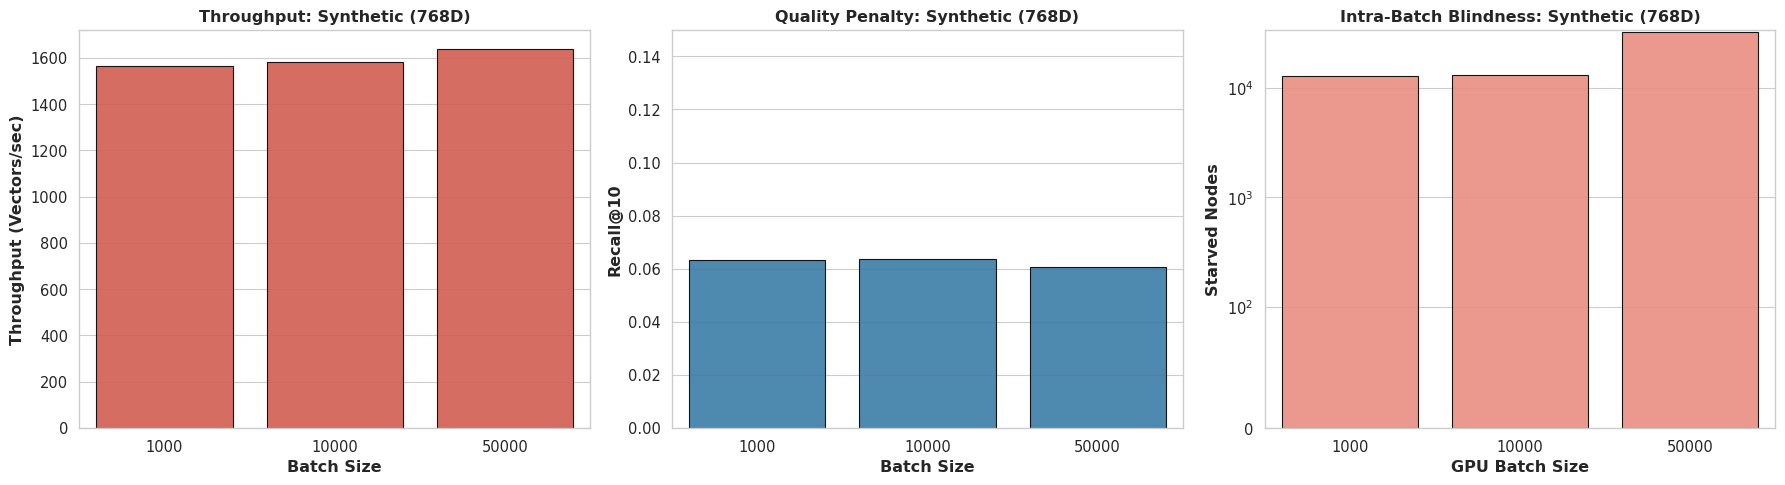

In [ ]:
sq2_df = df[(df['type'] == 'Hybrid CPU-GPU') & 
            (df['seed_size'] == 200000) & 
            (df['candidates_per_query'] == 3000) & 
            (df['beam_search_ef'] == 10)].copy()

# Treat batch size as categorical for discrete bars
sq2_df['batch_size'] = pd.Categorical(sq2_df['batch_size'], categories=[1000, 10000, 50000], ordered=True)

datasets = ['SIFT (128D)', 'Synthetic (768D)']

for ds_name in datasets:
    sub_df = sq2_df[sq2_df['dataset_clean'] == ds_name]
    if sub_df.empty: 
        continue
    
    # 1x3 Grid for clarity
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Throughput 
    sns.barplot(data=sub_df, x='batch_size', y='throughput_vec_sec', 
                color='#e74c3c', edgecolor='black', alpha=0.9, ax=axes[0])
    axes[0].set_title(f'Throughput: {ds_name}', fontweight='bold')
    axes[0].set_xlabel('Batch Size', fontweight='bold')
    axes[0].set_ylabel('Throughput (Vectors/sec)', fontweight='bold')
    
    # Recall 
    sns.barplot(data=sub_df, x='batch_size', y='recall_10', 
                color='#2980b9', edgecolor='black', alpha=0.9, ax=axes[1])
    axes[1].set_title(f'Quality Penalty: {ds_name}', fontweight='bold')
    axes[1].set_xlabel('Batch Size', fontweight='bold')
    axes[1].set_ylabel('Recall@10', fontweight='bold')
    if ds_name == 'Synthetic (768D)':
        axes[1].set_ylim(0, 0.15)
    else:
        axes[1].set_ylim(0, 1.0)
        
    # Starved Nodes 
    sns.barplot(data=sub_df, x='batch_size', y='starved_nodes', 
                color='salmon', edgecolor='black', alpha=0.9, ax=axes[2])
    axes[2].set_title(f'Intra-Batch Blindness: {ds_name}', fontweight='bold')
    axes[2].set_xlabel('GPU Batch Size', fontweight='bold')
    axes[2].set_ylabel('Starved Nodes', fontweight='bold')
    axes[2].set_yscale('symlog', linthresh=100)
    
    plt.tight_layout()
    clean_name = ds_name.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f'sq2_discrete_tradeoff_{clean_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

### Batch size vs Candidates

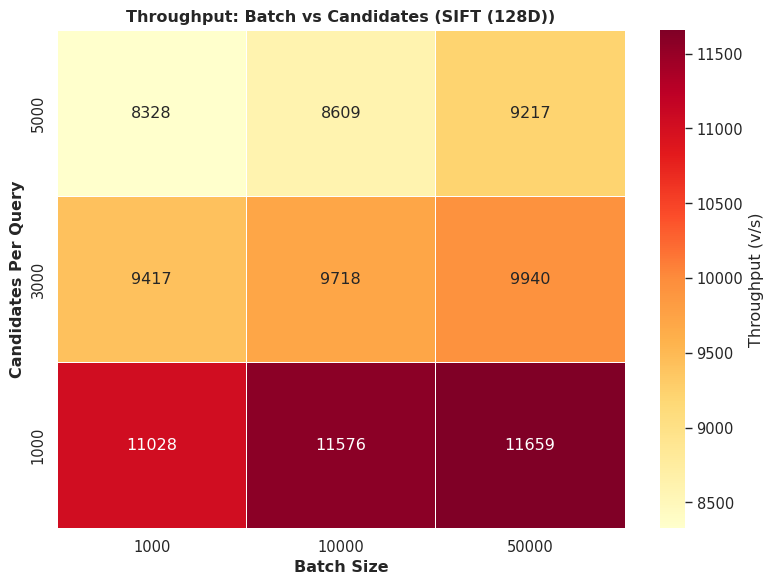

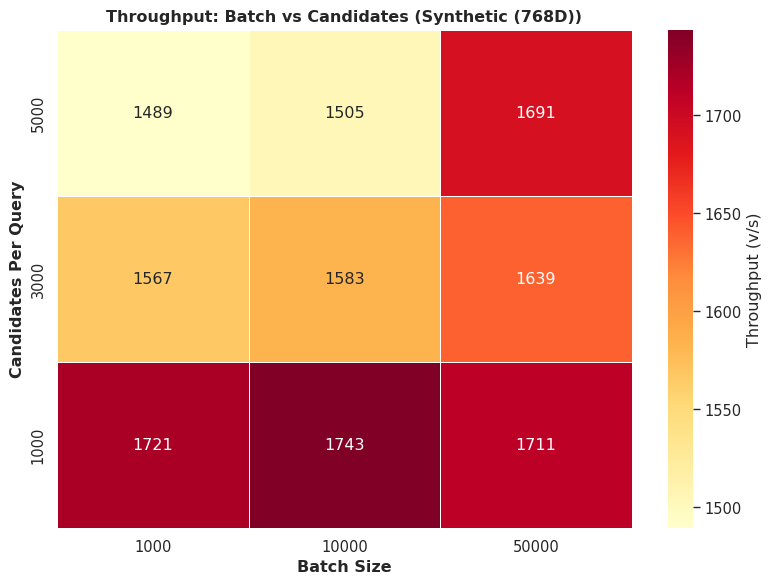

In [ ]:
heatmap_df = df[(df['type'] == 'Hybrid CPU-GPU') & 
                (df['seed_size'] == 200000) & 
                (df['beam_search_ef'] == 10)].copy()

datasets = ['SIFT (128D)', 'Synthetic (768D)']

for ds_name in datasets:
    sub_df = heatmap_df[heatmap_df['dataset_clean'] == ds_name]
    if sub_df.empty: continue
    
    # Pivot the data for the heatmap
    pivot_table = sub_df.pivot_table(
        values='throughput_vec_sec', 
        index='candidates_per_query', 
        columns='batch_size', 
        aggfunc='mean'
    )
    
    # Sort indexes so they read correctly (low to high)
    pivot_table = pivot_table.sort_index(ascending=False) 
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlOrRd", 
                linewidths=.5, cbar_kws={'label': 'Throughput (v/s)'})
    
    plt.title(f'Throughput: Batch vs Candidates ({ds_name})', fontweight='bold')
    plt.xlabel('Batch Size', fontweight='bold')
    plt.ylabel('Candidates Per Query', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'sq2_heatmap_{ds_name.replace(" ", "_")}.png', dpi=300)
    plt.show()

#### Phase distribution

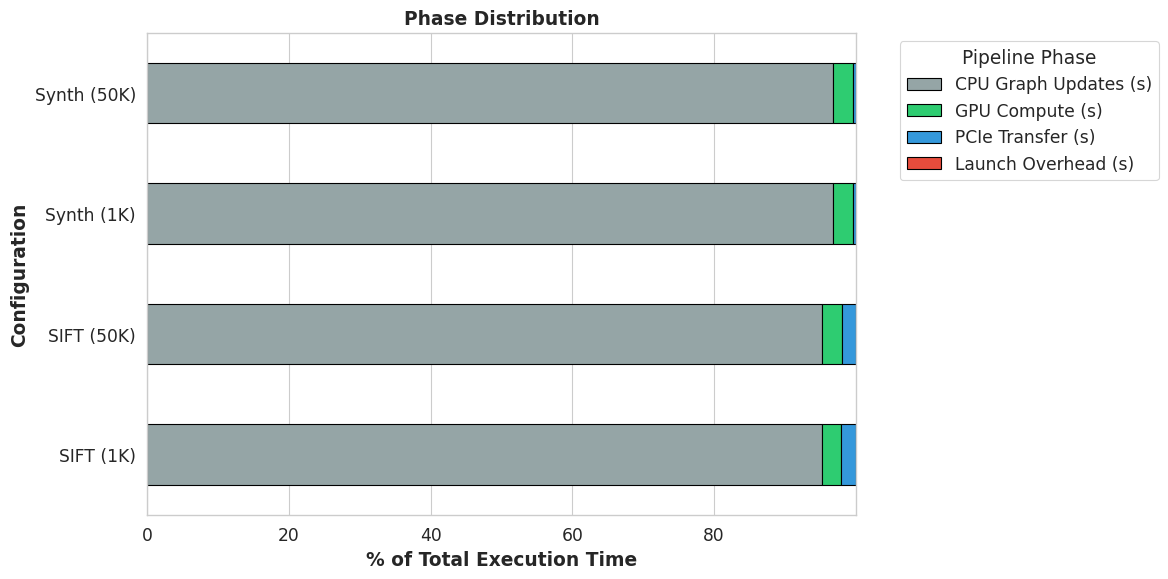

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)

# Your exact Nsight Data
data = {
    'Dataset': ['SIFT (1K)', 'SIFT (50K)', 'Synth (1K)', 'Synth (50K)'],
    'Total Time (s)': [106.40, 106.50, 666.20, 666.30],
    'GPU Compute (s)': [2.83, 3.06, 19.04, 19.24],
    'PCIe Transfer (s)': [2.26, 2.03, 2.42, 2.41],
    'Launch Overhead (s)': [0.026, 0.001, 0.027, 0.001]
}

df_time = pd.DataFrame(data)

# Calculate the CPU time (Total - GPU stuff)
df_time['CPU Graph Updates (s)'] = df_time['Total Time (s)'] - (df_time['GPU Compute (s)'] + df_time['PCIe Transfer (s)'] + df_time['Launch Overhead (s)'])

# Convert to percentages for a clean stacked bar
metrics = ['CPU Graph Updates (s)', 'GPU Compute (s)', 'PCIe Transfer (s)', 'Launch Overhead (s)']
df_pct = df_time.copy()
for m in metrics:
    df_pct[m] = (df_time[m] / df_time['Total Time (s)']) * 100

colors = ['#95a5a6', '#2ecc71', '#3498db', '#e74c3c']

fig, ax = plt.subplots(figsize=(12, 6))
df_pct.set_index('Dataset')[metrics].plot(kind='barh', stacked=True, color=colors, ax=ax, edgecolor='black')

plt.title('Phase Distribution', fontweight='bold')
plt.xlabel('% of Total Execution Time', fontweight='bold')
plt.ylabel('Configuration', fontweight='bold')

# Move legend outside
plt.legend(title='Pipeline Phase', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('sq2_phase_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Candidates

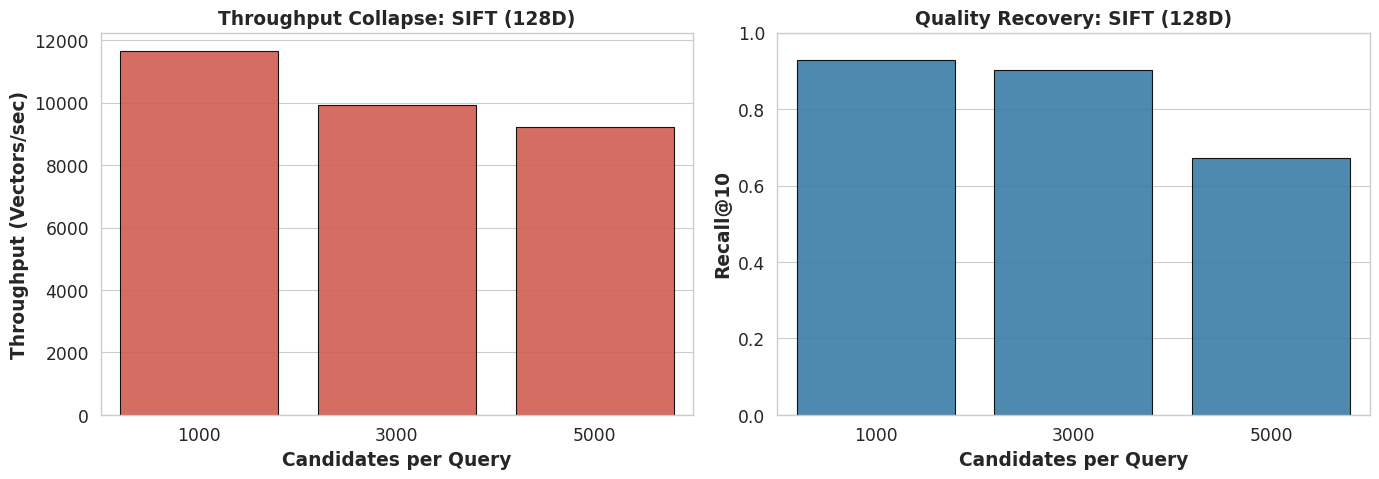

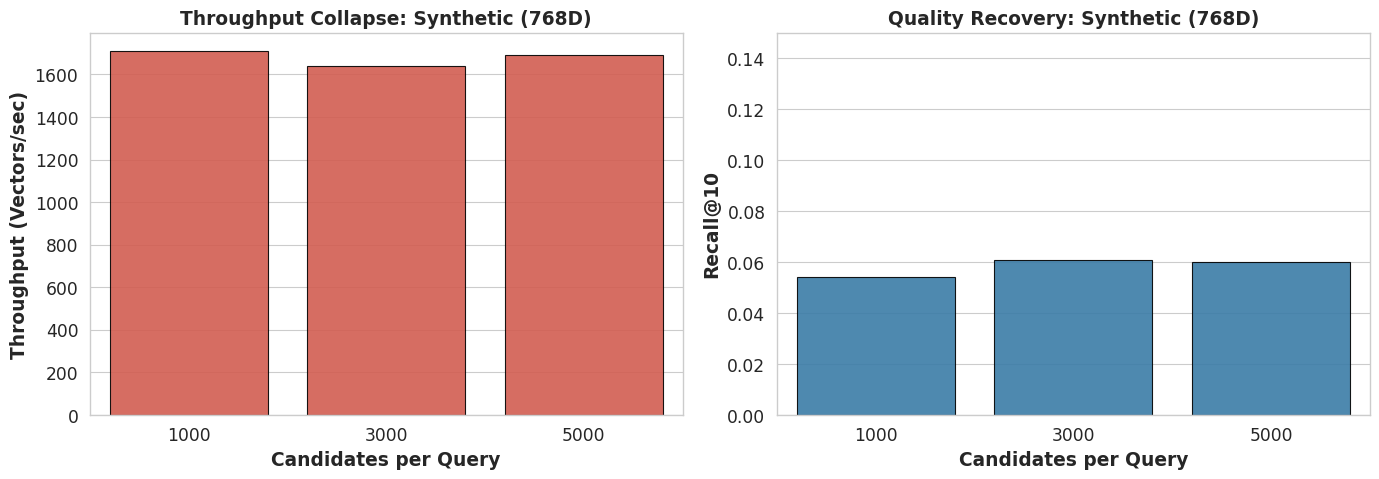

In [ ]:
sq3_df = df[(df['type'] == 'Hybrid CPU-GPU') & 
            (df['seed_size'] == 200000) & 
            (df['batch_size'] == 50000) & 
            (df['beam_search_ef'] == 10)].copy()

sq3_df['candidates_per_query'] = pd.Categorical(sq3_df['candidates_per_query'], 
                                                categories=[1000, 3000, 5000], ordered=True)

datasets = ['SIFT (128D)', 'Synthetic (768D)']

for ds_name in datasets:
    sub_df = sq3_df[sq3_df['dataset_clean'] == ds_name]
    if sub_df.empty: 
        continue
    
    # 1x2 Grid 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Throughput 
    sns.barplot(data=sub_df, x='candidates_per_query', y='throughput_vec_sec', 
                color='#e74c3c', edgecolor='black', alpha=0.9, ax=axes[0])
    axes[0].set_title(f'Throughput Collapse: {ds_name}', fontweight='bold')
    axes[0].set_xlabel('Candidates per Query', fontweight='bold')
    axes[0].set_ylabel('Throughput (Vectors/sec)', fontweight='bold')
    
    # Recall 
    sns.barplot(data=sub_df, x='candidates_per_query', y='recall_10', 
                color='#2980b9', edgecolor='black', alpha=0.9, ax=axes[1])
    axes[1].set_title(f'Quality Recovery: {ds_name}', fontweight='bold')
    axes[1].set_xlabel('Candidates per Query', fontweight='bold')
    axes[1].set_ylabel('Recall@10', fontweight='bold')
    
    # Scale Y-axis based on dataset
    if ds_name == 'Synthetic (768D)':
        axes[1].set_ylim(0, 0.15)
    else:
        axes[1].set_ylim(0, 1.0)
        
    plt.tight_layout()
    clean_name = ds_name.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f'sq3_candidates_macro_{clean_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

### Correlation with beam search

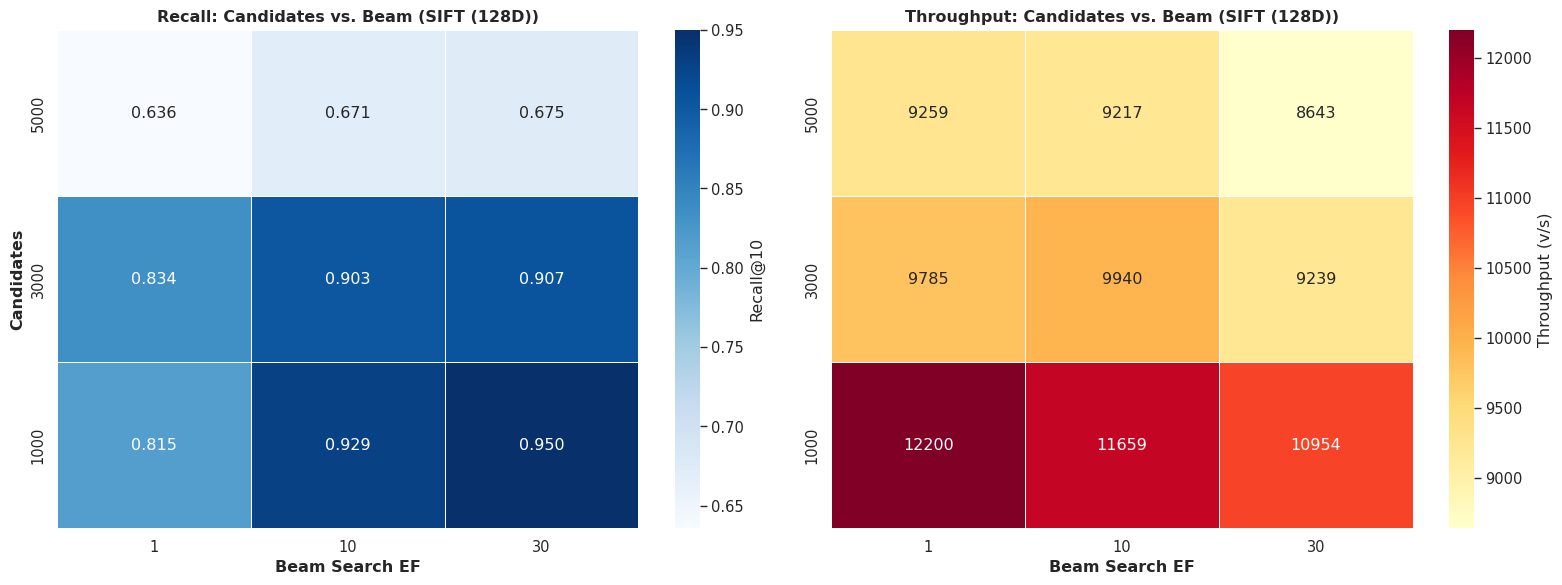

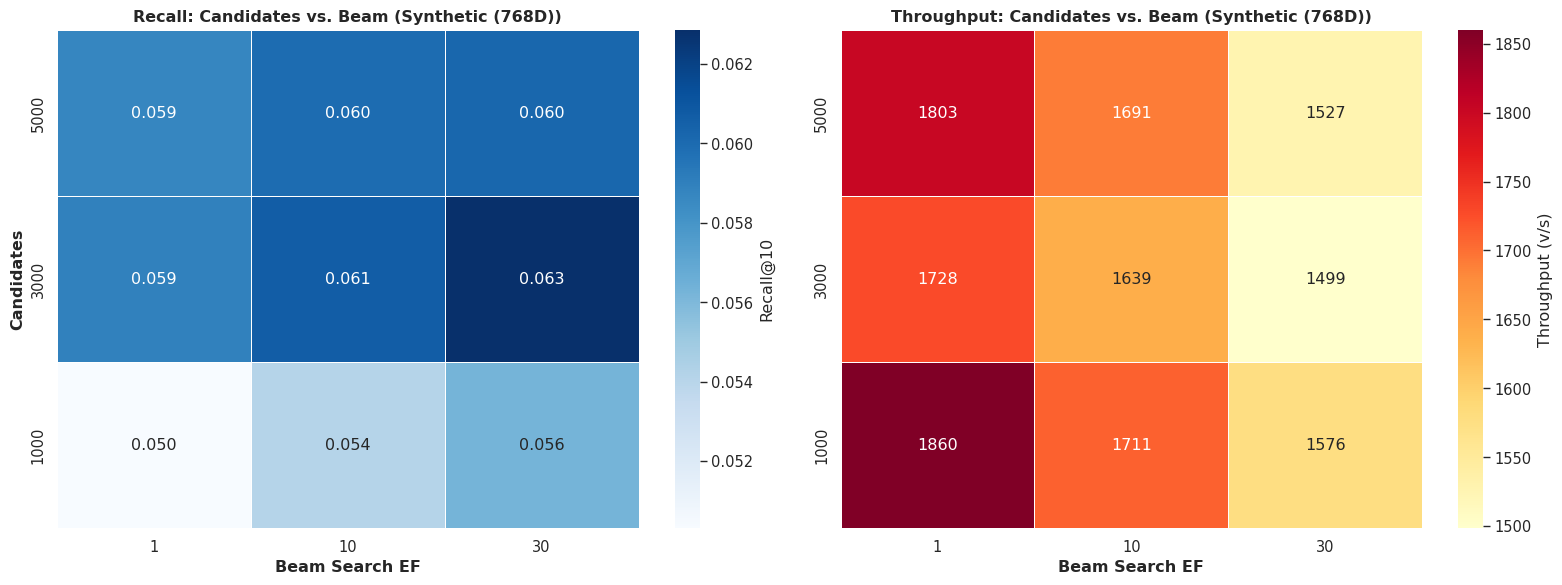

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ISOLATION: Lock the system at maximum concurrency
correlation_df = df[(df['type'] == 'Hybrid CPU-GPU') & 
                    (df['seed_size'] == 200000) & 
                    (df['batch_size'] == 50000)].copy()

datasets = ['SIFT (128D)', 'Synthetic (768D)']

for ds_name in datasets:
    sub_df = correlation_df[correlation_df['dataset_clean'] == ds_name]
    if sub_df.empty: 
        continue
    
    # Pivot for Recall (Proving the Paradox)
    pivot_recall = sub_df.pivot_table(
        values='recall_10', index='candidates_per_query', columns='beam_search_ef', aggfunc='mean'
    ).sort_index(ascending=False)
    
    # Pivot for Throughput (Proving the CPU Math Bottleneck)
    pivot_throughput = sub_df.pivot_table(
        values='throughput_vec_sec', index='candidates_per_query', columns='beam_search_ef', aggfunc='mean'
    ).sort_index(ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Recall Heatmap 
    sns.heatmap(pivot_recall, annot=True, fmt=".3f", cmap="Blues", 
                linewidths=.5, cbar_kws={'label': 'Recall@10'}, ax=axes[0])
    axes[0].set_title(f'Recall: Candidates vs. Beam ({ds_name})', fontweight='bold')
    axes[0].set_xlabel('Beam Search EF', fontweight='bold')
    axes[0].set_ylabel('Candidates', fontweight='bold')
    
    # Throughput Heatmap
    sns.heatmap(pivot_throughput, annot=True, fmt=".0f", cmap="YlOrRd", 
                linewidths=.5, cbar_kws={'label': 'Throughput (v/s)'}, ax=axes[1])
    axes[1].set_title(f'Throughput: Candidates vs. Beam ({ds_name})', fontweight='bold')
    axes[1].set_xlabel('Beam Search EF', fontweight='bold')
    axes[1].set_ylabel('') # Hide label for cleaner look
    
    plt.tight_layout()
    clean_name = ds_name.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f'sq3_sq4_interaction_{clean_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

# SQ4 Beam Search

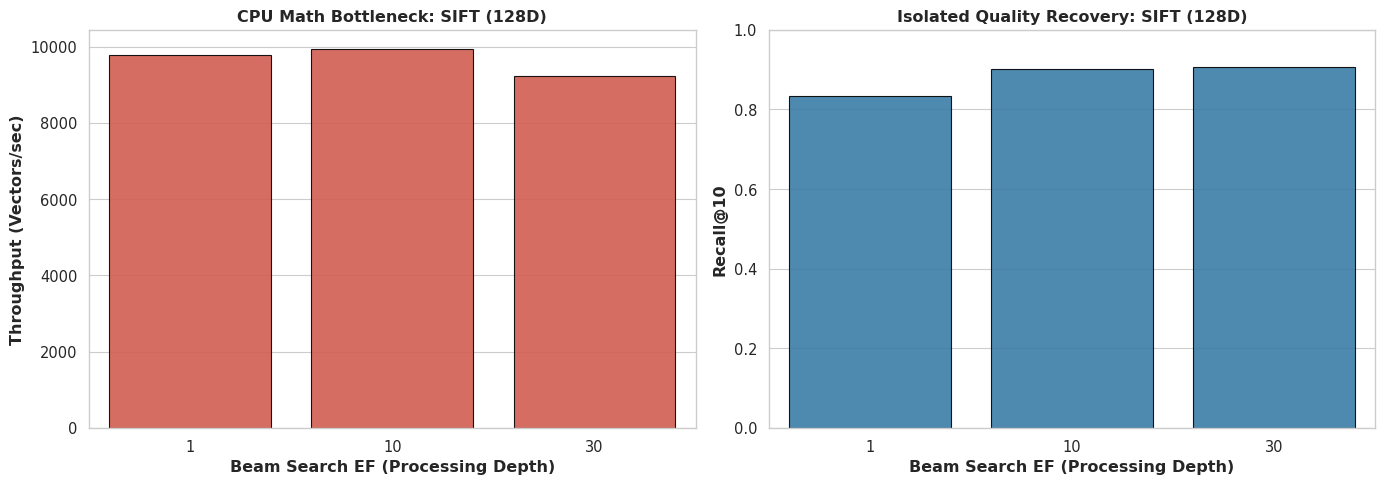

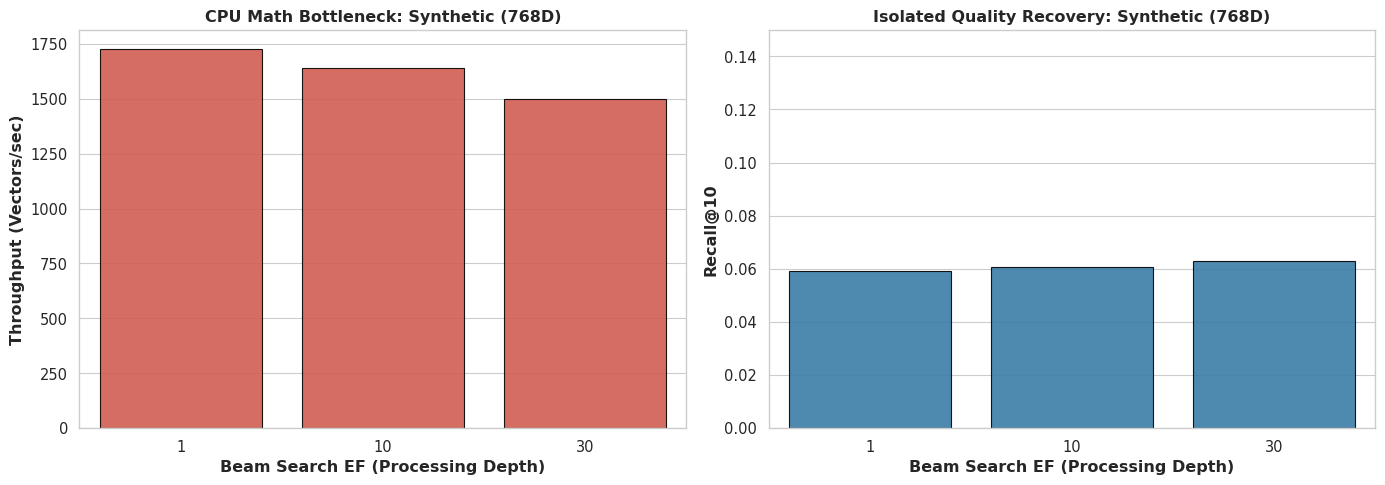

In [ ]:
# Lock candidates to isolate the CPU local search depth
sq4_df = df[(df['type'] == 'Hybrid CPU-GPU') & 
            (df['seed_size'] == 200000) & 
            (df['batch_size'] == 50000) & 
            (df['candidates_per_query'] == 3000)].copy()

# Treat beam_search_ef as categorical for discrete bars
sq4_df['beam_search_ef'] = pd.Categorical(sq4_df['beam_search_ef'], 
                                          categories=[1, 10, 30], ordered=True)

datasets = ['SIFT (128D)', 'Synthetic (768D)']

for ds_name in datasets:
    sub_df = sq4_df[sq4_df['dataset_clean'] == ds_name]
    if sub_df.empty: 
        continue
    
    # 1x2 Grid 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.barplot(data=sub_df, x='beam_search_ef', y='throughput_vec_sec', 
                color='#e74c3c', edgecolor='black', alpha=0.9, ax=axes[0])
    axes[0].set_title(f'CPU Math Bottleneck: {ds_name}', fontweight='bold')
    axes[0].set_xlabel('Beam Search EF (Processing Depth)', fontweight='bold')
    axes[0].set_ylabel('Throughput (Vectors/sec)', fontweight='bold')
    
    sns.barplot(data=sub_df, x='beam_search_ef', y='recall_10', 
                color='#2980b9', edgecolor='black', alpha=0.9, ax=axes[1])
    axes[1].set_title(f'Isolated Quality Recovery: {ds_name}', fontweight='bold')
    axes[1].set_xlabel('Beam Search EF (Processing Depth)', fontweight='bold')
    axes[1].set_ylabel('Recall@10', fontweight='bold')
    
    if ds_name == 'Synthetic (768D)':
        axes[1].set_ylim(0, 0.15)
    else:
        axes[1].set_ylim(0, 1.0)
        
    plt.tight_layout()
    clean_name = ds_name.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f'sq4_beam_macro_{clean_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

### Topology for SQ4

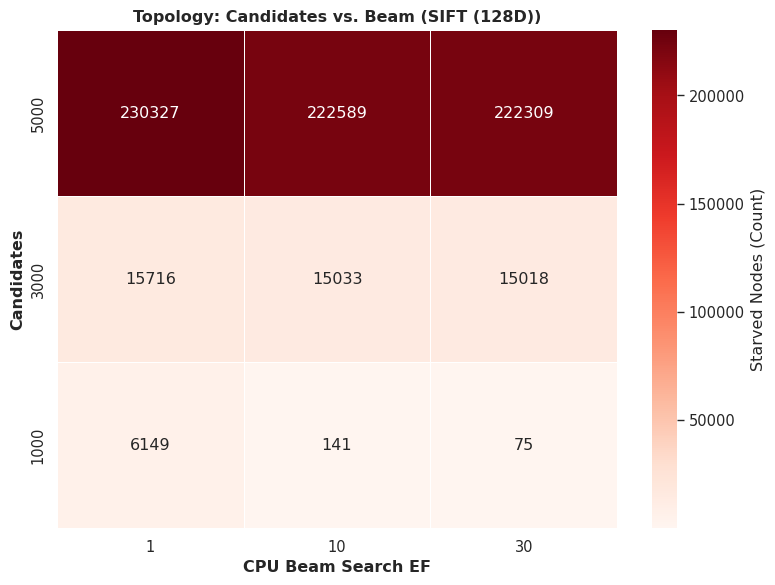

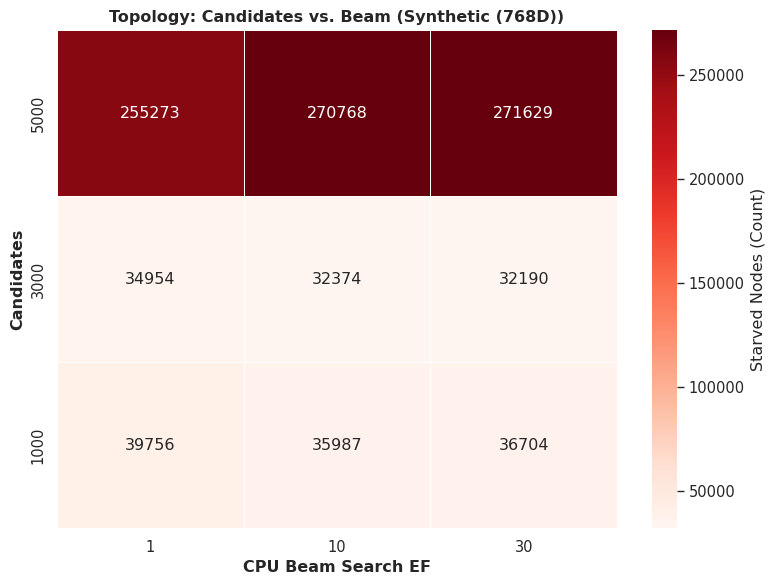

In [ ]:
topo_df = df[(df['type'] == 'Hybrid CPU-GPU') & 
             (df['seed_size'] == 200000) & 
             (df['batch_size'] == 50000)].copy()

datasets = ['SIFT (128D)', 'Synthetic (768D)']

for ds_name in datasets:
    sub_df = topo_df[topo_df['dataset_clean'] == ds_name]
    if sub_df.empty: 
        continue
    
    # Starved Nodes
    pivot_starved = sub_df.pivot_table(
        values='starved_nodes', index='candidates_per_query', columns='beam_search_ef', aggfunc='mean'
    ).sort_index(ascending=False)
    
    plt.figure(figsize=(8, 6))
    
    # We use a reversed Red heatmap (Red = Bad/Many starved nodes, White = Good/Few)
    sns.heatmap(pivot_starved, annot=True, fmt=".0f", cmap="Reds", 
                linewidths=.5, cbar_kws={'label': 'Starved Nodes (Count)'})
    
    plt.title(f'Topology: Candidates vs. Beam ({ds_name})', fontweight='bold')
    plt.xlabel('CPU Beam Search EF', fontweight='bold')
    plt.ylabel('Candidates', fontweight='bold')
    
    plt.tight_layout()
    clean_name = ds_name.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f'sq3_sq4_topology_{clean_name}.png', dpi=300)
    plt.show()

# General throughput vs quality

### Config extractor

In [ ]:
print("=== BEST HYBRID RUNS ===")

datasets = ['SIFT (128D)', 'Synthetic (768D)']

for ds in datasets:
    ds_df = df[df['dataset_clean'] == ds]
    hybrid_df = ds_df[ds_df['type'] == 'Hybrid CPU-GPU']
    baseline_df = ds_df[ds_df['type'] == 'Pure CPU Baseline']
    
    if hybrid_df.empty or baseline_df.empty:
        continue
        
    # Get Baseline metrics dynamically
    baseline_tput = baseline_df['throughput_vec_sec'].iloc[0]
    baseline_recall = baseline_df['recall_10'].iloc[0]

    def get_params(run):
        return f"(Seed: {run['seed_size']}, Batch: {run['batch_size']}, Cands: {run['candidates_per_query']}, Beam: {run['beam_search_ef']})"

    
    max_speed_run = hybrid_df.loc[hybrid_df['throughput_vec_sec'].idxmax()]
    
    max_qual_run = hybrid_df.loc[hybrid_df['recall_10'].idxmax()]
    
    faster_than_base = hybrid_df[hybrid_df['throughput_vec_sec'] > baseline_tput]
    if not faster_than_base.empty:
        balanced_run = faster_than_base.loc[faster_than_base['recall_10'].idxmax()]
        balanced_str = f"Tput: {balanced_run['throughput_vec_sec']:.0f} | Recall: {balanced_run['recall_10']:.3f} | {get_params(balanced_run)}"
    else:
        balanced_str = "No hybrid runs beat the baseline throughput."
    
    print(f"\n--- {ds} ---")
    print(f"BASELINE    | Tput: {baseline_tput:.0f} | Recall: {baseline_recall:.3f}")
    print(f"MAX SPEED   | Tput: {max_speed_run['throughput_vec_sec']:.0f} | Recall: {max_speed_run['recall_10']:.3f} | {get_params(max_speed_run)}")
    print(f"BALANCED    | {balanced_str}")
    print(f"MAX QUALITY | Tput: {max_qual_run['throughput_vec_sec']:.0f} | Recall: {max_qual_run['recall_10']:.3f} | {get_params(max_qual_run)}")

=== AUDIT: BEST HYBRID RUNS ===

--- SIFT (128D) ---
BASELINE    | Tput: 11553 | Recall: 0.983
MAX SPEED   | Tput: 23199 | Recall: 0.765 | (Seed: 0, Batch: 50000, Cands: 1000, Beam: 1)
BALANCED    | Tput: 12343 | Recall: 0.970 | (Seed: 0, Batch: 1000, Cands: 3000, Beam: 30)
MAX QUALITY | Tput: 7887 | Recall: 0.976 | (Seed: 200000, Batch: 1000, Cands: 5000, Beam: 30)

--- Synthetic (768D) ---
BASELINE    | Tput: 1285 | Recall: 0.075
MAX SPEED   | Tput: 4448 | Recall: 0.047 | (Seed: 0, Batch: 50000, Cands: 1000, Beam: 1)
BALANCED    | Tput: 2183 | Recall: 0.071 | (Seed: 0, Batch: 1000, Cands: 5000, Beam: 30)
MAX QUALITY | Tput: 2183 | Recall: 0.071 | (Seed: 0, Batch: 1000, Cands: 5000, Beam: 30)


### Pareto seed size

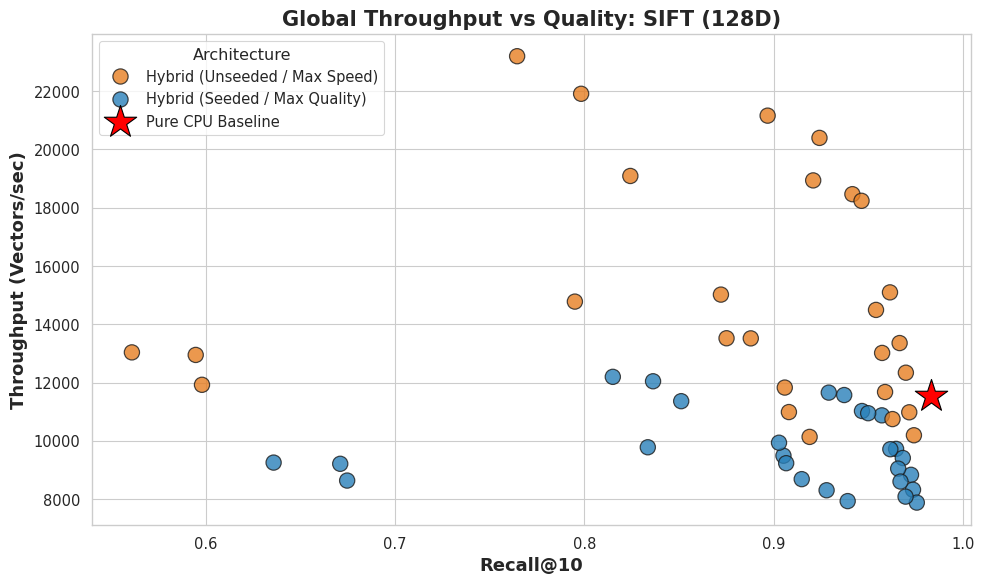

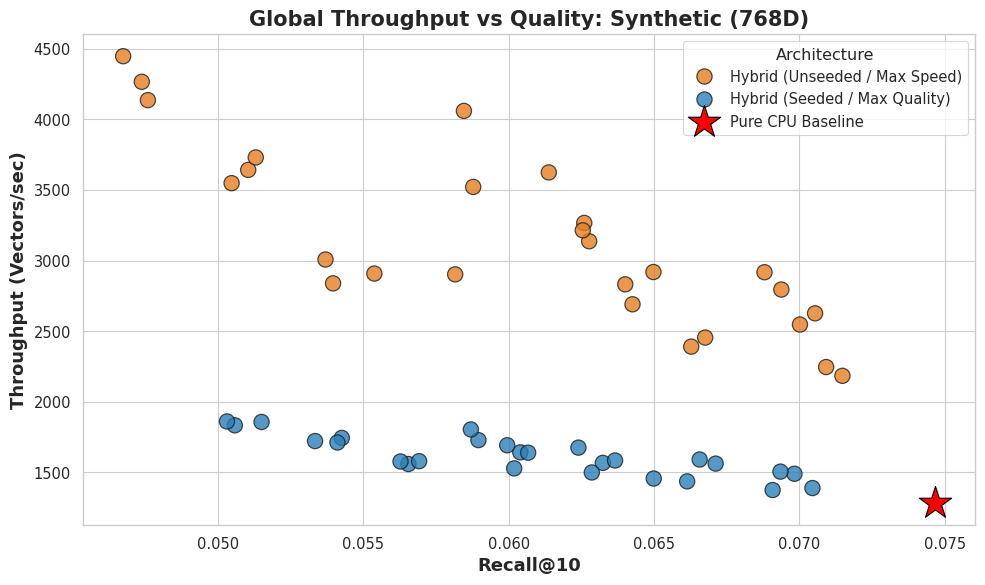

In [ ]:
hybrid_df = df[df['type'] == 'Hybrid CPU-GPU'].copy()
baseline_df = df[df['type'] == 'Pure CPU Baseline'].copy()

hybrid_df['Configuration'] = hybrid_df['seed_size'].apply(
    lambda x: 'Hybrid (Seeded / Max Quality)' if float(x) > 0 else 'Hybrid (Unseeded / Max Speed)'
)

datasets = ['SIFT (128D)', 'Synthetic (768D)']

for ds in datasets:
    # Filter by dataset
    ds_hybrid = hybrid_df[hybrid_df['dataset_clean'] == ds]
    ds_baseline = baseline_df[baseline_df['dataset_clean'] == ds]
    
    if ds_hybrid.empty:
        continue

    plt.figure(figsize=(10, 6))
    
    # Plot Hybrid points
    sns.scatterplot(
        data=ds_hybrid, 
        x='recall_10', 
        y='throughput_vec_sec', 
        hue='Configuration',
        palette={'Hybrid (Seeded / Max Quality)': '#2980b9', 'Hybrid (Unseeded / Max Speed)': '#e67e22'},
        s=120, 
        alpha=0.8, 
        edgecolor='k'
    )
    
    # Plot CPU Baseline directly from the dataframe
    if not ds_baseline.empty:
        plt.scatter(
            ds_baseline['recall_10'], 
            ds_baseline['throughput_vec_sec'], 
            color='red', 
            marker='*', 
            s=600, 
            label='Pure CPU Baseline', 
            edgecolor='black', 
            zorder=5
        )
    
    plt.title(f'Global Throughput vs Quality: {ds}', fontweight='bold', fontsize=15)
    plt.xlabel('Recall@10', fontweight='bold', fontsize=13)
    plt.ylabel('Throughput (Vectors/sec)', fontweight='bold', fontsize=13)
    
    plt.legend(title='Architecture', loc='best')
    plt.tight_layout()
    
    clean_name = ds.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f'global_pareto_{clean_name}.png', dpi=300)
    plt.show()